# Diabetes Risk Classifier

We are going to use the six step data processing workflow for data processing

## 1. Problem definition

> For the given dataset we are attempting to building a: `Build a multiclass classification model that predicts a patient's diabetes risk category (Low, Moderate, or High) using all available patient parameters in the dataset.`

(I have explained in detail in the readme)

## 2. Data

We have the dataset from Kaggle ([link here](https://www.kaggle.com/datasets/mansiaggarwal88/diabetes-risk-prediction/data)) is a huge csv file containing 15,000 rows of (artificially generated & random) data about patient having different parameters ...

The dataset doesn't exclusively contain training, validation and test set -> We shall have to split it into three sets.

## 3. Evaluation

Now we will be setting evaluation criteria by our own since nothing is mentioned in the dataset on Kaggle.
We will be setting three evaluation criterion:
* Primarily maximize the macro F1 score (since we are working on a mutliclass classification problem)
* Next we would attempt to achieve as much accuracy as possible
* And finally what we would want to make sure is that we handle errors properly -> especially `high risk patients being given as low risk`

## 4. Features

For details refer the `README.md`

## 5. Modelling

## 6. Experimentation

## Understanding the data

In [1]:
# Importing tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV

Now we have imported all the tools, we are ready to import data into our notebook

In [2]:
# Import entire dataset into a pandas dataframe
df = pd.read_csv(filepath_or_buffer='./data/diabetes_risk.csv')
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [3]:
# Import entire dataset into a pandas dataframe
df_without_patientID = pd.read_csv(filepath_or_buffer='./data/diabetes_risk.csv')
df_without_patientID.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [4]:
df_without_patientID = df_without_patientID.drop(['patient_id'], axis=1)
df_without_patientID.head()

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


## 2. Data
Now we will
* Understand the data givenn
* Assess the quality of data
* Conduct EDA
* Conclude our research

In [5]:
# Take a look at the shape of the dataframe
df.shape

(15000, 19)

In [6]:
df.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket',
       'diabetes_risk'],
      dtype='str')

We have 19 columns out of which
> `patient_id` - identifier <br>
> `diabetes_risk` - target variable <br>
> `'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket'` - features

In [7]:
# Take a look at the dtype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

In [8]:
# Check only the necessary columns
df.iloc[[i for i in range(5)], [i for i in range(1, 18)]].info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5 non-null      int64  
 1   gender                    5 non-null      str    
 2   city                      5 non-null      str    
 3   bmi                       5 non-null      float64
 4   family_history_diabetes   5 non-null      str    
 5   physical_activity_level   5 non-null      str    
 6   diet_type                 5 non-null      str    
 7   smoking_status            5 non-null      str    
 8   alcohol_consumption       5 non-null      str    
 9   hours_sleep_per_night     5 non-null      float64
 10  stress_level              5 non-null      int64  
 11  fasting_blood_sugar       5 non-null      int64  
 12  hba1c_level               5 non-null      float64
 13  blood_pressure_systolic   5 non-null      int64  
 14  blood_pressure_diastolic 

Out of the 17 features under consideration we have:
* Numeric - age, bmi, hours_sleep_per_night, stress_level, fasting_blood_sugar, hba1c_level, blood_pressure_systolic, blood_pressure_diastolic, waist_circumference_cm
* Categorical - gender, city, physical_activity_level, smoking_status, alcohol_consumptionx
* Binary - family_history_diabetes, diet_type, 

In [9]:
# A look at the missing values
df.isna().sum()

patient_id                     0
age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

We have missing values from columns: 
* 472 from smoking_status
* 3788 from alcohol_consumption
* 463 from income_bracket

Next we explore the data we have one by one

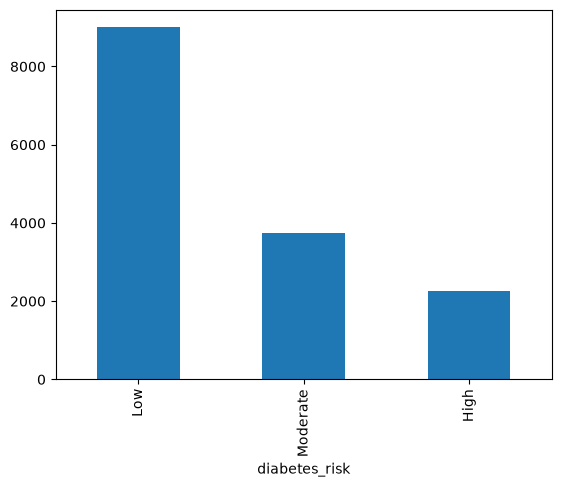

In [10]:
# Let's look at the diabetes_risk distribution over the 3 classes
df['diabetes_risk'].value_counts().plot(kind='bar');

We see the data contains an imbalance towards the class `Low` and an unusual difference between it's peer classes. Hence we need to keep in mind that the model is being trained on data that has an imbalance towards class `Low`

### Next we will one by go over the numerical features and see how they are distributed over

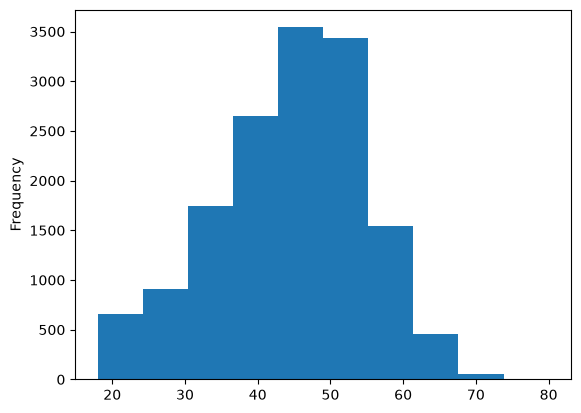

In [11]:
# Age
df['age'].plot(kind='hist');

We see a bell curve indicating:
* Data has majority patients aging between 45-55 (approximately from the graph)
* Our model is being loaded with data that has higher probability being associated with patient aged in the above mentioned range

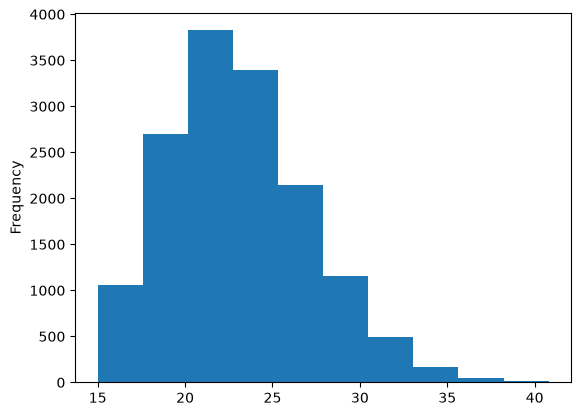

In [12]:
# BMI
df['bmi'].plot(kind='hist');

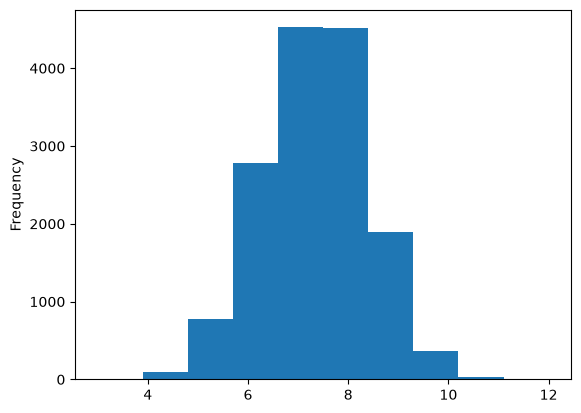

In [13]:
# Hours of sleep
df['hours_sleep_per_night'].plot(kind='hist');

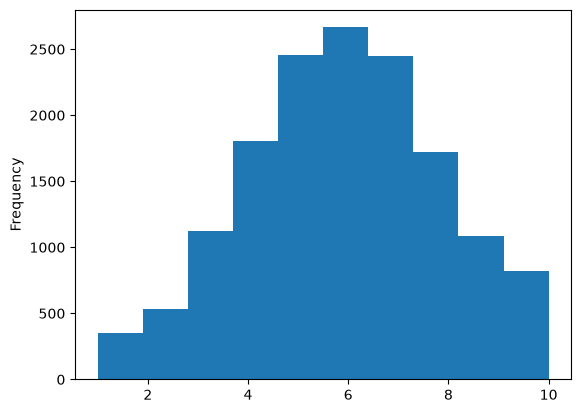

In [14]:
# Stress level
df['stress_level'].plot(kind='hist');

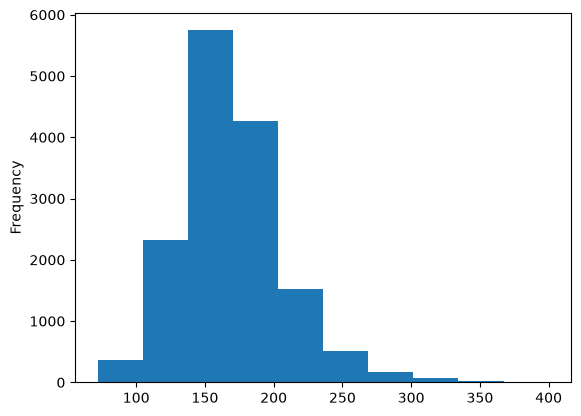

In [15]:
# Fasting blood sugar level
df['fasting_blood_sugar'].plot(kind='hist');

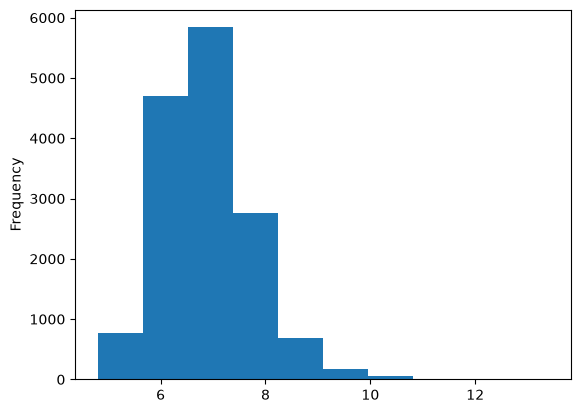

In [16]:
# HbA1c levels
df['hba1c_level'].plot(kind='hist');

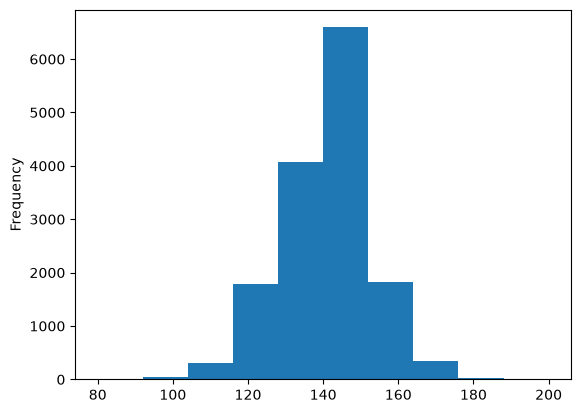

In [17]:
# Blood pressure - Systolic
df['blood_pressure_systolic'].plot(kind='hist');

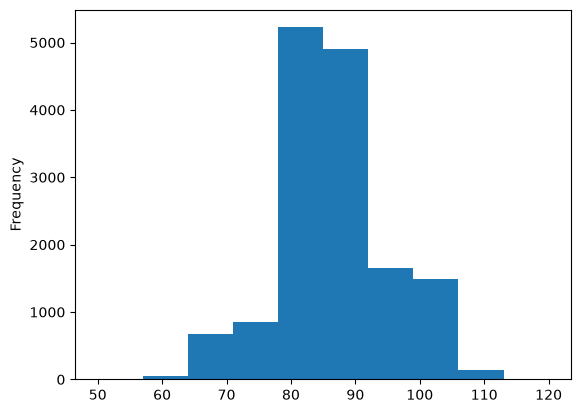

In [18]:
# Blood pressure - Diastolic
df['blood_pressure_diastolic'].plot(kind='hist');

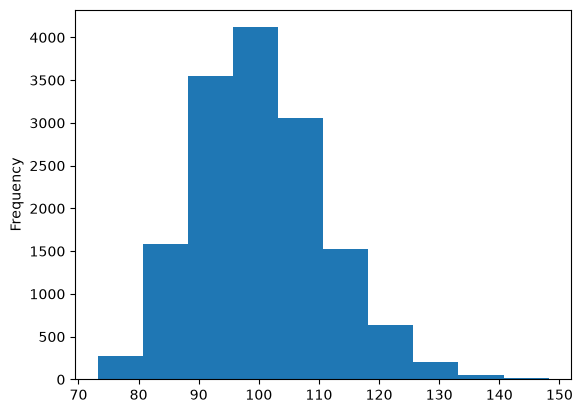

In [19]:
# Waist circumference in cm
df['waist_circumference_cm'].plot(kind='hist');

### Now we consider the categorical features

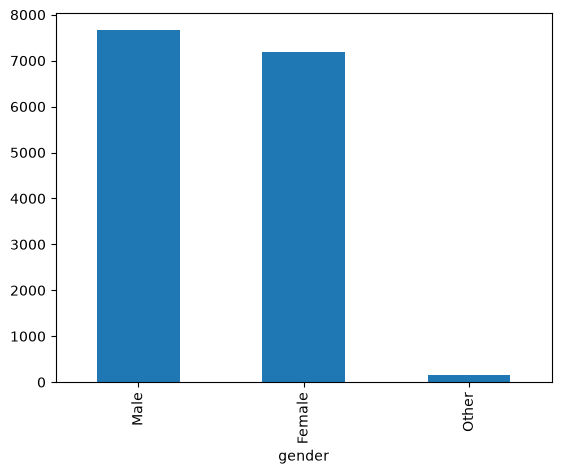

In [20]:
# gender
df['gender'].value_counts().plot(kind='bar');

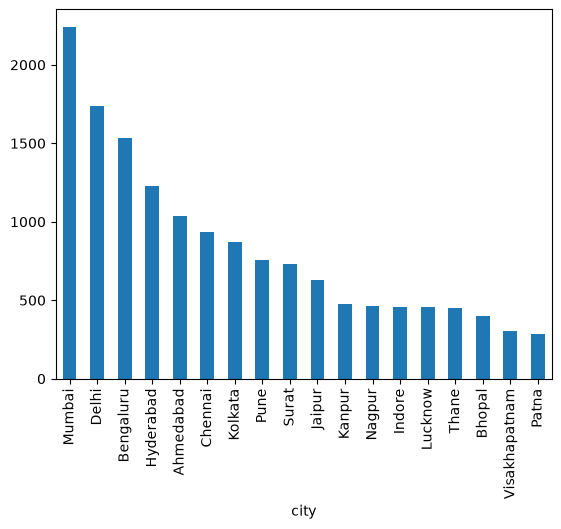

In [21]:
# city
df['city'].value_counts().plot(kind='bar');

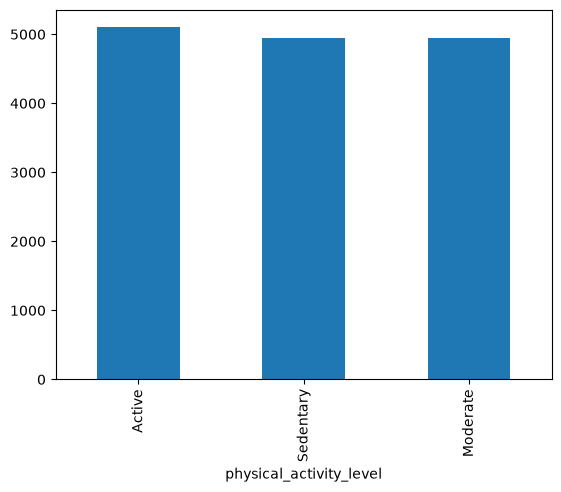

In [22]:
# physical_activity_level
df['physical_activity_level'].value_counts().plot(kind='bar');

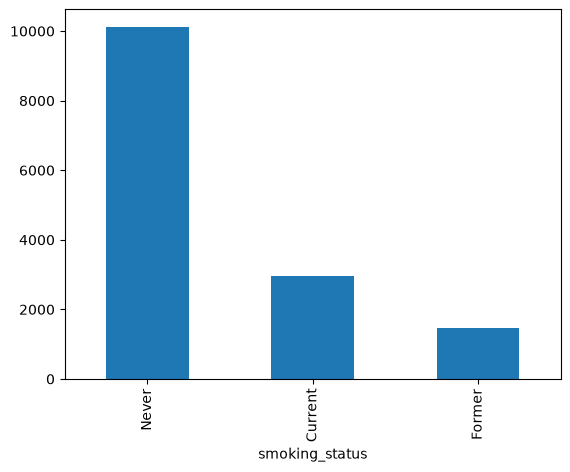

In [23]:
# smoking_status
df['smoking_status'].value_counts().plot(kind='bar');

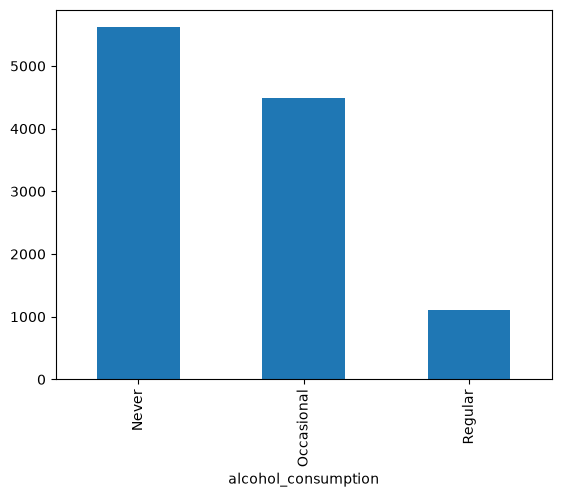

In [24]:
# alcohol_consumption
df['alcohol_consumption'].value_counts().plot(kind='bar');

### Next Let's look at the correlation between different features

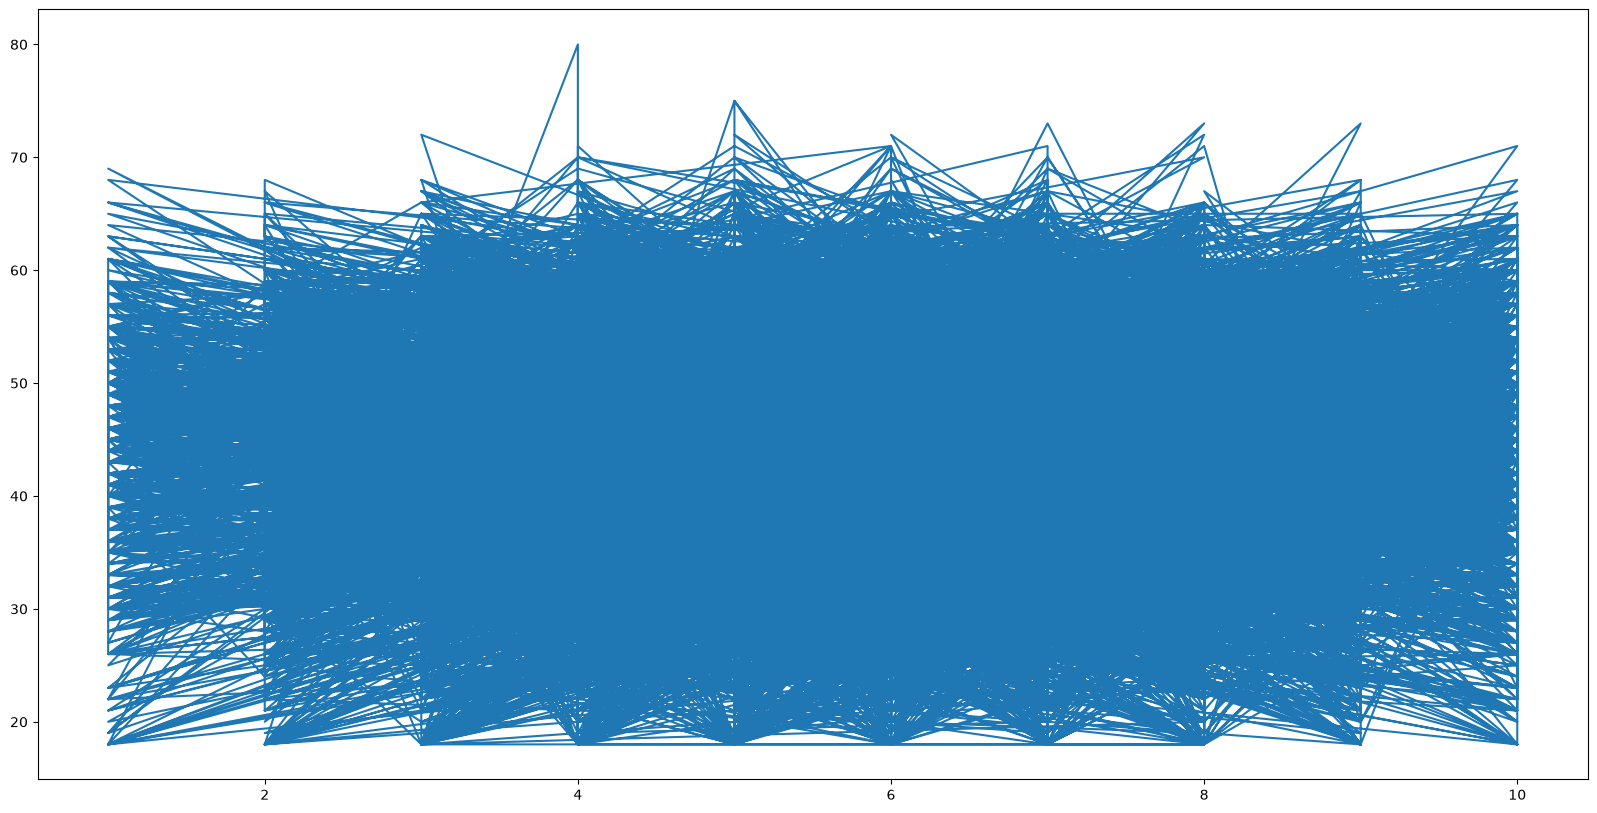

In [25]:
# Stress vs age
X = df['stress_level']
y = df['age']

fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(X, y)
plt.show();

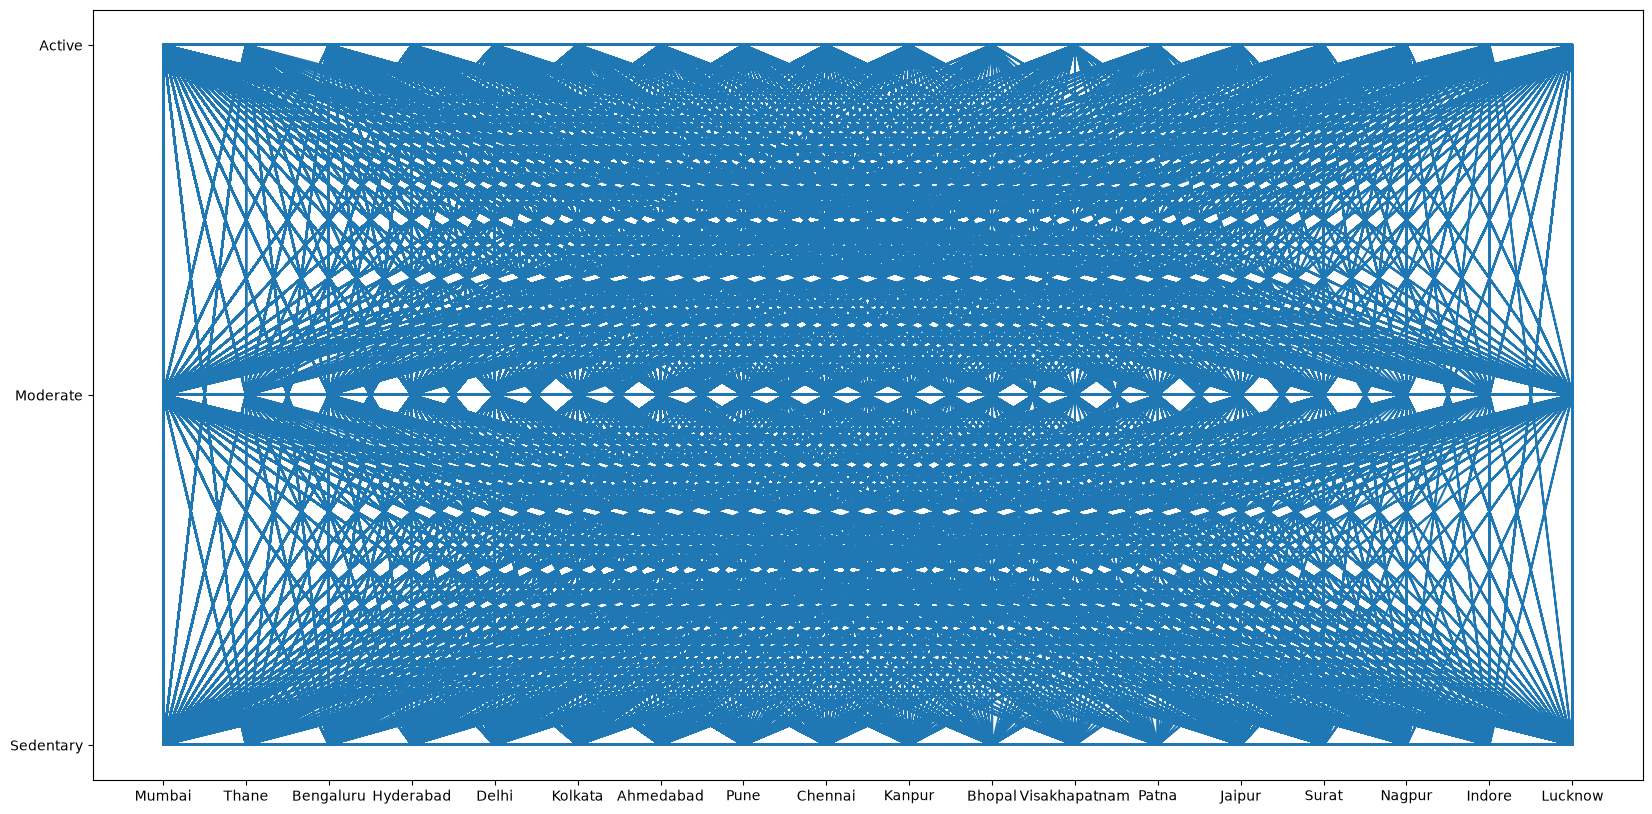

In [26]:
# city vs physical_activity_level
X = df['city']
y = df['physical_activity_level']

fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(X, y)
plt.show();

### Concluding our data analysis results

## 4. Feature Engineering

In [27]:
df_without_patientID.head()

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


Now let's take a look at the missing data

In [28]:
df_without_patientID.isna().sum()

age                            0
gender                         0
city                           0
bmi                            0
family_history_diabetes        0
physical_activity_level        0
diet_type                      0
smoking_status               472
alcohol_consumption         3788
hours_sleep_per_night          0
stress_level                   0
fasting_blood_sugar            0
hba1c_level                    0
blood_pressure_systolic        0
blood_pressure_diastolic       0
waist_circumference_cm         0
income_bracket               463
diabetes_risk                  0
dtype: int64

We dont have any numerical columns missing data, only the categorical columns

### Dealing with missing categorical values

In [29]:
# smoking_status
df_without_patientID['smoking_status'].value_counts(), df_without_patientID['smoking_status'].isna().sum()

(smoking_status
 Never      10119
 Current     2946
 Former      1463
 Name: count, dtype: int64,
 np.int64(472))

In [30]:
# alcohol_consumption
df_without_patientID['alcohol_consumption'].value_counts(), df_without_patientID['alcohol_consumption'].isna().sum()

(alcohol_consumption
 Never         5616
 Occasional    4483
 Regular       1113
 Name: count, dtype: int64,
 np.int64(3788))

In [31]:
# income_bracket
df_without_patientID['income_bracket'].value_counts(), df_without_patientID['income_bracket'].isna().sum()

(income_bracket
 Middle    7305
 High      3844
 Low       3388
 Name: count, dtype: int64,
 np.int64(463))

Now seeing above we get there are three classes to each categorical feature having missing data.

We have two options ahead to fill in the missing values:
1. Randomly assign it / Assign it to the class having higher frequency
2. Create a new class called 'Missing'


But there are a few points to consider before we try to fill in the missing values:
* `alcohol_consumption` has almost 25% percent missing values. Hence trying to assign it to the higher frequency class ('Never') is introducing information that might be incorrect.
* Other two classes `smoking_status` and `income_bracket` contain relatively lesser missing values. However putting in 'Never' in the smoking_status introduces assumptions & secondly assigning 'Middle' as the default value to missing data might be undesirable.

In [32]:
# filling Missing in the smoking_status
df_without_patientID['smoking_status'] = df_without_patientID['smoking_status'].fillna('Missing')

In [33]:
# filling Missing in the alcohol_consumption
df_without_patientID['alcohol_consumption'] = df_without_patientID['alcohol_consumption'].fillna('Missing')

In [34]:
# filling Missing in the income_bracket
df_without_patientID['income_bracket'] = df_without_patientID['income_bracket'].fillna('Missing')

In [35]:
df_without_patientID.head(25)

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
5,58,Male,Hyderabad,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,High,Low
6,42,Female,Hyderabad,22.5,No,Sedentary,Non-Vegetarian,Missing,Missing,7.0,10,190,7.5,140,81,95.0,High,Moderate
7,42,Female,Delhi,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,Middle,High
8,57,Male,Mumbai,20.3,Yes,Moderate,Non-Vegetarian,Current,Never,4.8,10,186,7.4,170,91,92.3,High,Moderate
9,44,Male,Mumbai,24.1,No,Moderate,Non-Vegetarian,Current,Occasional,6.2,8,178,7.6,150,90,102.5,High,Moderate


Now we have successfully filled all the missing values. Better to save the completed dataset in a new csv

In [36]:
df_without_patientID.to_csv(r'C:\Users\shrey\Desktop\diabetes-classification\data\diabetes_risk_missing_values_filled.csv', index=False)

### Encoding the data

Lets split the dataset into X(features) & y(target)

In [37]:
X = df_without_patientID.drop(columns=['diabetes_risk'])
y = df_without_patientID['diabetes_risk']

In [38]:
# Now its time to split the data into training and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X,
                                                   y,
                                                   test_size=0.15,
                                                   random_state=42,
                                                   stratify=y)

In [39]:
# Now we further split temp into train and validate
X_train, X_val, y_train, y_val = train_test_split(X_temp,
                                                  y_temp,
                                                  test_size=0.1765,
                                                  random_state=42,
                                                  stratify=y_temp)

In [40]:
# Lets confirm the shape of each set
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((10499, 17), (2251, 17), (2250, 17), (10499,), (2251,), (2250,))

In [41]:
y_train.value_counts(normalize=True), y_val.value_counts(normalize=True), y_test.value_counts(normalize=True)

(diabetes_risk
 Low         0.599962
 Moderate    0.250024
 High        0.150014
 Name: proportion, dtype: float64,
 diabetes_risk
 Low         0.600178
 Moderate    0.250111
 High        0.149711
 Name: proportion, dtype: float64,
 diabetes_risk
 Low         0.600000
 Moderate    0.249778
 High        0.150222
 Name: proportion, dtype: float64)

In [42]:
# defining a list containing our categorical features
categorical_features = [
    'gender',
    'city',
    'family_history_diabetes',
    'physical_activity_level',
    'diet_type',
    'smoking_status',
    'alcohol_consumption',
    'income_bracket']

There are two functions to be carried out here:
* `fit()` - where the engine learns about the categorical features -> vocab formation - done only on training set
* `transform()` - is the encoding part - done on all three sets

**Note:** We never fit the validation and test sets on encoder since it can cause `data leakage`

In [43]:
# fitting the data
encoder.fit(X_train[categorical_features])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequent

In [44]:
encoder.categories_

[array(['Female', 'Male', 'Other'], dtype=object),
 array(['Ahmedabad', 'Bengaluru', 'Bhopal', 'Chennai', 'Delhi',
        'Hyderabad', 'Indore', 'Jaipur', 'Kanpur', 'Kolkata', 'Lucknow',
        'Mumbai', 'Nagpur', 'Patna', 'Pune', 'Surat', 'Thane',
        'Visakhapatnam'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['Active', 'Moderate', 'Sedentary'], dtype=object),
 array(['Non-Vegetarian', 'Pescatarian', 'Vegan', 'Vegetarian'],
       dtype=object),
 array(['Current', 'Former', 'Missing', 'Never'], dtype=object),
 array(['Missing', 'Never', 'Occasional', 'Regular'], dtype=object),
 array(['High', 'Low', 'Middle', 'Missing'], dtype=object)]

In [45]:
# Transforming the training, val & test sets
X_train_encoded = encoder.transform(X_train[categorical_features])
X_val_encoded = encoder.transform(X_val[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

In [46]:
X_train_encoded.shape

(10499, 42)

In [47]:
X_train_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 83992 stored elements and shape (10499, 42)>

In [48]:
X_train_encoded_dense = X_train_encoded.toarray()
X_train_encoded_dense

array([[1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(10499, 42))

In [49]:
# Listing out the numerical features
numerical_features = ['age', 
                     'bmi', 
                     'hours_sleep_per_night', 
                     'stress_level', 
                     'fasting_blood_sugar', 
                     'hba1c_level', 
                     'blood_pressure_systolic', 
                     'blood_pressure_diastolic', 
                     'waist_circumference_cm']

# Extracting the numerical data
X_train_numeric = X_train[numerical_features]
X_val_numeric = X_val[numerical_features]
X_test_numeric = X_test[numerical_features]

#### Combining the data

First we need to convert the encoded sets into dataframes. Right now they are in the form of CSR (compressed sparse row), ie, stored in a memory efficient way such that only the non-zero elements are stored.
We will first convert it to dataframes and then concatenate the two (the order might change from the original version)

In [50]:
# Converting the encoded CSR to dataframes
X_train_encoded_df = pd.DataFrame(X_train_encoded.toarray(),
                                  columns=encoder.get_feature_names_out(categorical_features),
                                  index=X_train.index)

X_val_encoded_df = pd.DataFrame(X_val_encoded.toarray(),
                                columns=encoder.get_feature_names_out(categorical_features),
                                index=X_val.index)

X_test_encoded_df = pd.DataFrame(X_test_encoded.toarray(),
                                 columns=encoder.get_feature_names_out(categorical_features),
                                 index=X_test.index)

In [51]:
# Concatenating all three dataframes with their respective numerical counterparts
X_train_final = pd.concat([X_train_numeric, 
                           X_train_encoded_df],
                          axis=1)

X_val_final = pd.concat([X_val_numeric, 
                           X_val_encoded_df],
                          axis=1)

X_test_final = pd.concat([X_test_numeric, 
                           X_test_encoded_df],
                          axis=1)

In [52]:
X_train_final

,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,gender_Female,...,smoking_status_Missing,smoking_status_Never,alcohol_consumption_Missing,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,income_bracket_High,income_bracket_Low,income_bracket_Middle,income_bracket_Missing
8953,62,28.2,6.5,7,169,7.3,148,90,107.4,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8712,45,20.1,8.0,7,163,6.5,140,83,91.7,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7229,42,21.8,6.0,10,176,7.2,130,70,97.2,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7245,56,23.0,7.0,9,129,6.3,150,84,102.9,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14793,34,25.2,9.0,6,173,6.5,126,84,100.8,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9074,24,23.7,8.0,7,114,5.6,148,100,104.3,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4028,34,25.9,7.0,9,213,7.4,150,84,108.9,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2113,45,21.7,8.5,7,189,8.0,120,100,97.1,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6611,53,21.9,10.0,5,198,7.3,144,80,91.4,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [53]:
X_val_final

,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,gender_Female,...,smoking_status_Missing,smoking_status_Never,alcohol_consumption_Missing,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,income_bracket_High,income_bracket_Low,income_bracket_Middle,income_bracket_Missing
1167,42,26.0,7.0,10,196,7.8,140,108,103.8,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12834,45,21.0,8.0,3,139,6.6,130,82,95.1,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8248,18,25.7,8.0,3,93,5.5,140,70,108.3,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6280,56,27.8,5.5,6,165,6.8,162,80,108.8,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
11704,49,29.0,6.0,7,213,7.7,164,90,116.9,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3219,48,27.6,8.0,6,171,7.0,149,80,109.2,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12011,41,15.0,8.0,7,146,6.1,120,78,82.1,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
10578,53,22.9,6.0,7,165,6.5,140,86,95.3,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4660,45,21.9,7.0,7,181,6.5,143,80,99.9,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [54]:
X_test_final

,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,gender_Female,...,smoking_status_Missing,smoking_status_Never,alcohol_consumption_Missing,alcohol_consumption_Never,alcohol_consumption_Occasional,alcohol_consumption_Regular,income_bracket_High,income_bracket_Low,income_bracket_Middle,income_bracket_Missing
541,55,17.6,8.0,8,143,6.2,133,87,89.3,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
8747,41,20.9,5.0,8,165,6.8,148,88,92.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7538,42,27.8,5.5,10,160,7.0,158,90,110.9,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10654,45,23.6,6.0,5,173,7.5,144,90,97.7,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3080,40,19.1,6.0,9,196,7.2,130,80,90.1,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,43,20.1,8.0,8,150,6.5,142,100,94.2,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1358,33,19.1,6.0,6,185,6.6,128,78,85.6,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10187,36,25.0,6.0,8,147,6.3,140,80,107.4,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
14760,46,22.8,6.5,6,136,6.0,122,90,103.2,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Modelling

We will use the mental model of `levels` for this part of our project. Beginnning with baseline model, we will continue training and evaluating until we reach the final model

The models we will be using are:
1. DummyClassifier
2. LogisticRegression
3. DecisionTrees
4. RandomForest


### DummyClassifier

This model makes predictions by ignoring the input and using simple rules (based on the strategy selected) returns the target label prediction.

[Documentation Link](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html#sklearn.dummy.DummyClassifier)



In [55]:
# Importing the model
from sklearn.dummy import DummyClassifier

# We will create a strategy list and then use each strategy once to compare the results
strategy_list = ["most_frequent", "prior", "stratified", "uniform", "constant"]

In [56]:
# Declaring the score_list list
score_list = []


# Loop to fit, predict and score the model
for strat in strategy_list:
    # Initialize the model
    if strat == "stratified" or strat == "uniform":
        dummy_clf = DummyClassifier(strategy=strat, random_state=42)
    elif strat == "constant":
        dummy_clf = DummyClassifier(strategy=strat, random_state=42, constant="Moderate")
    else:
        dummy_clf = DummyClassifier(strategy=strat)
        
    # Fit the training data into the estimator
    dummy_clf.fit(X_train_final, y_train)
        
    # Predict on the X_val
    dummy_clf.predict(X_val_final)

    # Score and append it to the list
    score_list.append(dummy_clf.score(X_val_final, y_val))

In [57]:
score_list

[0.6001776988005331,
 0.6001776988005331,
 0.4504664593513994,
 0.32030208796090626,
 0.2501110617503332]

In [58]:
score_list.index(max(score_list))

0

In [59]:
# hence we observe that the maximum accuracy is reache when strategy='most_frequent'
dummy_clf = DummyClassifier(strategy="most_frequent")

# Fit the training data into the estimator
dummy_clf.fit(X_train_final, y_train)
        
# Predict on the X_val
dummy_clf.predict(X_val_final)

# Score and append it to the list
dummy_score_most_frequent = dummy_clf.score(X_val_final, y_val)

### Logistic Regression

Despite it's name, this model is used in classification problems rather than regression problems.

[Documentation Link](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [109]:
# Importing the model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Creating the model
clf = LogisticRegression(max_iter=1000, random_state=42)

In [110]:
# Train the model
clf.fit(X_train_final, y_train)

# Make predictions on validation data
y_val_pred = clf.predict(X_val_final)

C:\Users\shrey\miniconda3\envs\scipy_test\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [111]:
# Evaluate
accuracy_log_reg = accuracy_score(y_val, y_val_pred)
macro_f1_log_reg = f1_score(y_val, y_val_pred, average="macro")

print("Accuracy:", accuracy_log_reg)
print("Macro F1:", macro_f1_log_reg)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Accuracy: 0.7676588183029764
Macro F1: 0.7063535387935659

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.69      0.72       337
         Low       0.84      0.90      0.87      1351
    Moderate       0.57      0.50      0.53       563

    accuracy                           0.77      2251
   macro avg       0.72      0.70      0.71      2251
weighted avg       0.76      0.77      0.76      2251


Confusion Matrix:
[[ 234   16   87]
 [  17 1214  120]
 [  63  220  280]]


### DecisionTreeClassifier

This is a non-parametric supervised learning model that uses simple rules inferred from data features and classifies the target

[Documentation Link](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)

In [112]:
from sklearn.tree import DecisionTreeClassifier

# 1. Create the model
decision_tree = DecisionTreeClassifier(random_state=42)

In [113]:
# 2. Train the model
decision_tree.fit(X_train_final, y_train)

# 3. Make predictions on validation data
y_val_pred = decision_tree.predict(X_val_final)

In [114]:
# 4. Evaluate
accuracy_dtc = accuracy_score(y_val, y_val_pred)
macro_f1_dtc = f1_score(y_val, y_val_pred, average="macro")

print("Accuracy:", accuracy_dtc)
print("Macro F1:", macro_f1_dtc)

# 5. Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# 6. Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Accuracy: 0.7192358951577077
Macro F1: 0.6609181135626558

Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.67      0.68       337
         Low       0.83      0.83      0.83      1351
    Moderate       0.48      0.47      0.47       563

    accuracy                           0.72      2251
   macro avg       0.66      0.66      0.66      2251
weighted avg       0.72      0.72      0.72      2251


Confusion Matrix:
[[ 227   19   91]
 [  22 1125  204]
 [  85  211  267]]


#### RandomForestClassifier

A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

[Documentation Link](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

In [115]:
# Importing the models
from sklearn.ensemble import RandomForestClassifier

# 1. Create the model
clf_rfc = RandomForestClassifier(random_state=42)

In [116]:
# 2. Train the model
clf.fit(X_train_final, y_train)

# 3. Make predictions on validation data
y_val_pred = clf.predict(X_val_final)

C:\Users\shrey\miniconda3\envs\scipy_test\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [117]:
# 4. Evaluate
accuracy_rfc = accuracy_score(y_val, y_val_pred)
macro_f1_rfc = f1_score(y_val, y_val_pred, average="macro")

print("Accuracy:", accuracy_rfc)
print("Macro F1:", macro_f1_rfc)

# 5. Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# 6. Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Accuracy: 0.7676588183029764
Macro F1: 0.7063535387935659

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.69      0.72       337
         Low       0.84      0.90      0.87      1351
    Moderate       0.57      0.50      0.53       563

    accuracy                           0.77      2251
   macro avg       0.72      0.70      0.71      2251
weighted avg       0.76      0.77      0.76      2251


Confusion Matrix:
[[ 234   16   87]
 [  17 1214  120]
 [  63  220  280]]


### Time to compare performace

With that we have fitted and evaluated each estimator's performance.

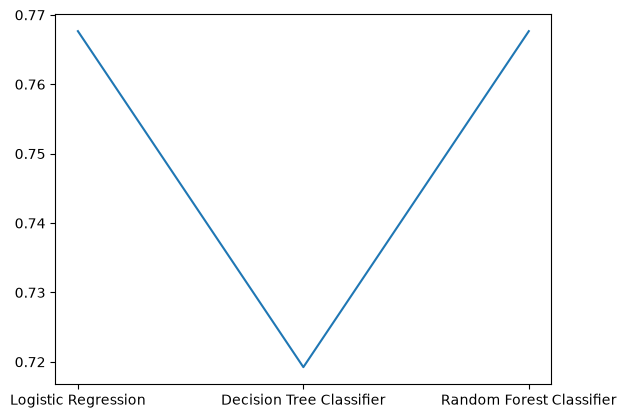

In [69]:
# Doing the accuracy plot
x = ["Logistic Regression", "Decision Tree Classifier", "Random Forest Classifier"]
y = [accuracy_log_reg, accuracy_dtc, accuracy_rfc]

fig, ax = plt.subplots()
ax.plot(x, y)

plt.show()

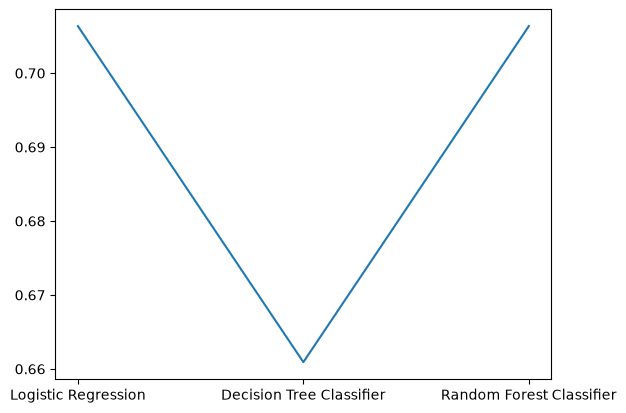

In [70]:
# Doing the macro_f1 plot
x = ["Logistic Regression", "Decision Tree Classifier", "Random Forest Classifier"]
y = [macro_f1_log_reg, 
     macro_f1_dtc, 
     macro_f1_rfc]

fig, ax = plt.subplots()
ax.plot(x, y)

plt.show()

On comparing all three models we arrive at the conclusion that `RandomForestClassifier` is the optimum choice for the problem.

### Tuning the Hyperparameters

In [71]:
clf_rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [75]:
# Initialize the base estimator again
clf_rfc = RandomForestClassifier(n_jobs=1,
                                 random_state=42)

# Create a list of hyperparameters we are going to tune
param_grid = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", "log2", None],
    "max_depth": [None, 10, 20, 30],
    "max_leaf_nodes": [None, 15, 30, 50],
    "max_samples": [0.5, 0.75, 1.0],
    "min_samples_split": [2, 5, 10]
    # "min_samples_split": [2, 5]
}

# Initialize the GridSearchCV with cross validation = 5
grid_search = GridSearchCV(estimator=clf_rfc,
                           param_grid=param_grid,
                           scoring="f1_macro",
                           cv=5,
                           n_jobs=-1)

# Fit and search
grid_search.fit(X_train_final, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'max_leaf_nodes': [None, 15, ...], 'max_samples': [0.5, 0.75, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for calla

In [76]:
# Print the best hyperparameters
print("Best Hyperparameters: \n")
grid_search.best_params_

Best Hyperparameters: 



{'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': 50,
 'max_samples': 1.0,
 'min_samples_split': 10,
 'n_estimators': 100}

In [80]:
# Best cross-validation score
print(f'Best CV score: {grid_search.best_score_}')

Best CV score: 0.7380440551953121


In [81]:
# View the best parameters after tuning with GridSearchCV
grid_search.best_params_

{'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': 50,
 'max_samples': 1.0,
 'min_samples_split': 10,
 'n_estimators': 100}

In [83]:
final_clf = RandomForestClassifier(max_depth=None,
                                   max_features=None,
                                   max_leaf_nodes=50,
                                   max_samples=1.0,
                                   min_samples_split=10,
                                   n_estimators=100)

In [84]:
final_clf.fit(X_train_final, y_train)

,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",1.0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of

In [85]:
# Make predictions on validation data
y_val_pred = final_clf.predict(X_val_final)

In [86]:
# 4. Evaluate
accuracy_rfc = accuracy_score(y_val, y_val_pred)
macro_f1_rfc = f1_score(y_val, y_val_pred, average="macro")

print("Accuracy:", accuracy_rfc)
print("Macro F1:", macro_f1_rfc)

# 5. Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# 6. Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Accuracy: 0.7952021323856064
Macro F1: 0.7517915058246979

Classification Report:
              precision    recall  f1-score   support

        High       0.84      0.73      0.78       337
         Low       0.86      0.90      0.88      1351
    Moderate       0.61      0.59      0.60       563

    accuracy                           0.80      2251
   macro avg       0.77      0.74      0.75      2251
weighted avg       0.79      0.80      0.79      2251


Confusion Matrix:
[[ 245    7   85]
 [   6 1215  130]
 [  39  194  330]]


Bingooo. We observe that on scoring our final estimator on the test set we get an accuracy of 0.87!
Now its time we save our model and export it.

### Saving the model
We will use `joblib` for the purpose. Along with the model we might have to save the preprocessing code as well because that is going to be required as well.

In [100]:
import joblib

# Save the final model
joblib.dump(final_clf, "diabetes-risk-classifier.pkl")

# Save the encoder (since our preprocessing only contains this)
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

## Scores on final model

In [106]:
import joblib

loaded_clf = joblib.load("diabetes-risk-classifier.pkl")

In [119]:
clf.fit(X_train_final, y_train)
decision_tree.fit(X_train_final, y_train)
clf_rfc.fit(X_train_final, y_train)
loaded_clf.fit(X_train_final, y_train)

C:\Users\shrey\miniconda3\envs\scipy_test\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",1.0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of

In [120]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": clf,
    "Decision Tree": decision_tree,
    "Random Forest": clf_rfc,
    "Tuned Random Forest": loaded_clf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_val_final)

    results.append({
        "Model": name,
        "Validation Macro F1": f1_score(y_val, y_pred, average="macro"),
        "Validation Accuracy": accuracy_score(y_val, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Validation Macro F1,Validation Accuracy
0,Logistic Regression,0.706354,0.767659
1,Decision Tree,0.660918,0.719236
2,Random Forest,0.743888,0.791648
3,Tuned Random Forest,0.752607,0.796979
